# 1_segmentation.ipynb

Purpose: Load U²-Net and generate binary masks of clothing regions
Steps:

Load U²-Net model (u2net.pth)

Input: image from test_images/

Output: binary mask saved in outputs/

Show original + mask

## 🧩 Step 1: Clothing Segmentation with U²-Net

In this notebook, we will use the pre-trained U²-Net model to segment the clothing region from the input image. The output will be a binary mask highlighting the clothing region.

## 📦 Imports and Setup

In [44]:
import os
from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Add project root to sys.path
import sys

# Adjust this path as needed (relative to your notebook location)
project_root = os.path.abspath("..")  # or "." if your notebook is already in root
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now imports will work
from segmentation.model.u2net import U2NET  # or any other internal module


## 📁 Paths and Configuration

In [45]:
image_path = '../test_images/01_test_image.jpg'  # your image
model_path = '../models/u2net.pth'
output_mask_path = '../outputs/01_mask.png'

# Image size
target_size = (320, 320)

## 🧠 Load Pre-trained U²-Net Model

In [46]:
def load_model(model_path):
    model = U2NET(3, 1)
    model.load_state_dict(torch.load(model_path, map_location='cpu', weights_only=True))
    model.eval()
    return model


In [47]:
model = load_model(model_path)

## 🧪 Preprocess the Test Image

In [48]:
# Preprocess image for U²-Net
def preprocess(image_path):
    transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],  # mean
                             [0.229, 0.224, 0.225])  # std
    ])
    image = Image.open(image_path).convert("RGB")
    original = image.copy()  # Keep original for later visualization
    image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return image_tensor, original

# Apply preprocessing
input_tensor, original_image = preprocess(image_path)


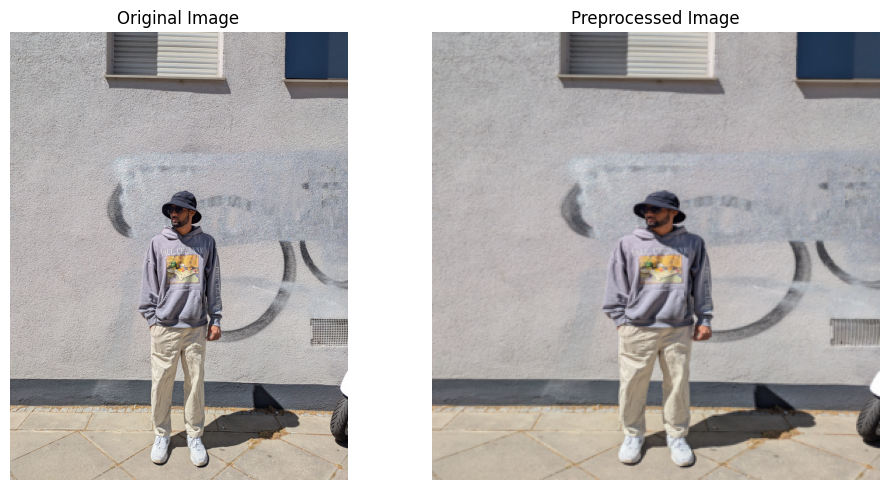

In [49]:
# Visualize original and preprocessed image
def show_preprocessing(original, preprocessed_tensor):
    # Convert tensor to image format for visualization
    preprocessed_image = preprocessed_tensor.squeeze(0).clone()
    preprocessed_image = preprocessed_image * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)  # unnormalize std
    preprocessed_image = preprocessed_image + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)  # unnormalize mean
    preprocessed_image = preprocessed_image.clamp(0,1)

    preprocessed_image = transforms.ToPILImage()(preprocessed_image)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(preprocessed_image)
    ax[1].set_title("Preprocessed Image")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

# Show both images
show_preprocessing(original_image, input_tensor)


## 🪄 Generate Mask from Preprocessed Image

In [51]:
# Run the model on the input image and generate a binary mask
def predict_mask(model, image_tensor):
    with torch.no_grad():
        d1, *_ = model(image_tensor)
        pred = d1[:, 0, :, :]
        pred = (pred - pred.min()) / (pred.max() - pred.min())  # Normalize to [0, 1]
        mask = (pred.squeeze().cpu().numpy() * 255).astype('uint8')  # Convert to 0–255
        return Image.fromarray(mask)

# Generate the mask
mask_image = predict_mask(model, input_tensor)

# Resize the mask to match original image size
mask_image = mask_image.resize(original_image.size)

# Save the mask
output_mask_path = '../outputs/01_mask.png'
mask_image.save(output_mask_path)

print(f"✅ Mask saved to: {output_mask_path}")


✅ Mask saved to: ../outputs/01_mask.png


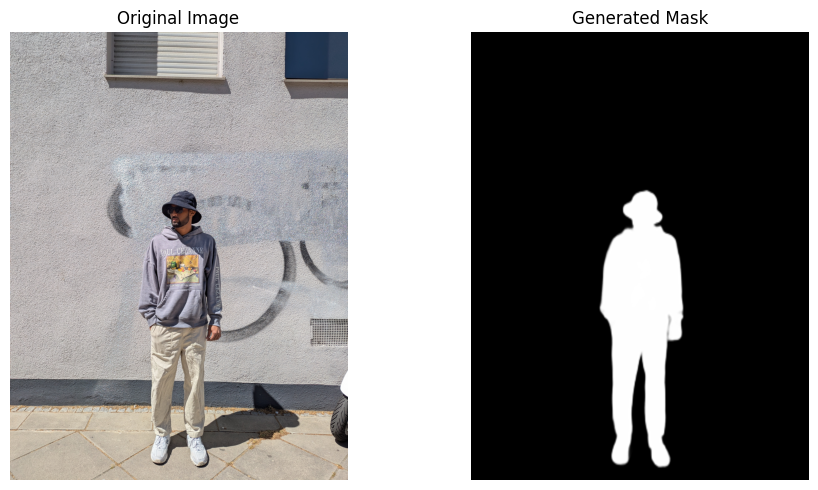

In [52]:
# Visualize original image and its corresponding mask
def show_images(original, mask):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(original)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Generated Mask")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

# Show both
show_images(original_image, mask_image)


## 🧼 Apply Mask to Extract the Person

✅ Masked person image saved to: ../outputs/01masked_full.jpg


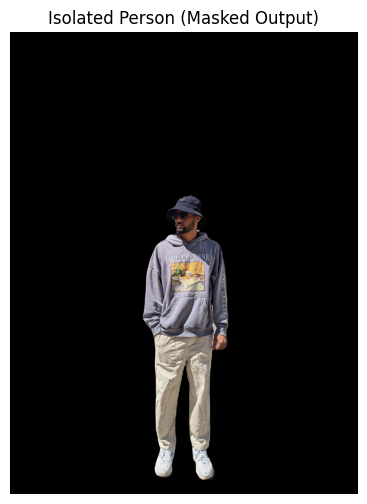

In [55]:
# 📌 Apply the mask to extract the person from the background

from torchvision.transforms import ToTensor, ToPILImage

def apply_mask(original_image, mask_image):
    """
    Applies a binary mask to the original image to isolate the foreground (person).
    """
    # Convert to tensors
    original_tensor = ToTensor()(original_image)
    mask_tensor = ToTensor()(mask_image)

    # Ensure mask is single channel and binarized (0 or 1)
    mask_tensor = (mask_tensor > 0.5).float()

    # Expand mask to 3 channels
    if mask_tensor.shape[0] == 1:
        mask_tensor = mask_tensor.repeat(3, 1, 1)

    # Apply mask
    person_only = original_tensor * mask_tensor

    # Convert back to PIL image
    return ToPILImage()(person_only)

# 🖼️ Run mask application
masked_person = apply_mask(original_image, mask_image)

# 💾 Save output
masked_person_path = '../outputs/01masked_full.jpg'
masked_person.save(masked_person_path)
print(f"✅ Masked person image saved to: {masked_person_path}")

# 👀 Display
plt.figure(figsize=(5, 6))
plt.imshow(masked_person)
plt.title("Isolated Person (Masked Output)")
plt.axis("off")
plt.show()


### ✅ Done! We now have the person segmented and isolated.

### 👉 Proceed to **Style Transfer** notebook for next step.